In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

In [3]:
products = [p for p in prices['product'].unique() if str(p).startswith("OXYGEN")]

In [4]:
prices = prices[prices["product"].isin(products)].copy()

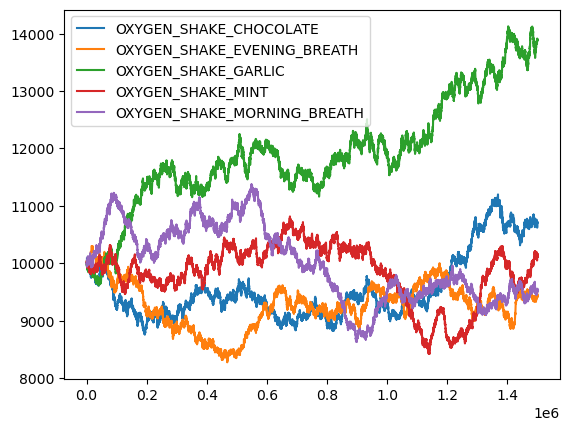

In [5]:
for p in products:
    plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [6]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

pairs:   0%|          | 0/25 [00:00<?, ?it/s]

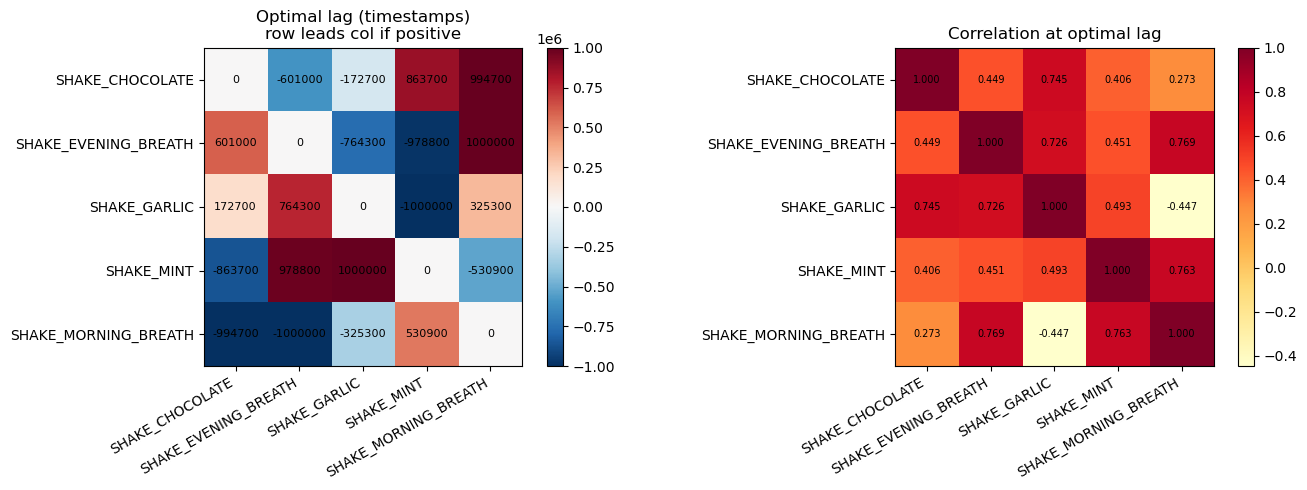

Timestamp step: 100 | Searching +/-1000000 ts = +/-10000 array shifts per pair

Pairwise optimal lead-lag summary (row LEADS col by N timestamps):
  SHAKE_CHOCOLATE vs SHAKE_EVENING_BREATH: lag=-601000 ts  corr=0.4494  -> SHAKE_EVENING_BREATH leads SHAKE_CHOCOLATE by 601000 ts
  SHAKE_CHOCOLATE vs SHAKE_GARLIC: lag=-172700 ts  corr=0.7448  -> SHAKE_GARLIC leads SHAKE_CHOCOLATE by 172700 ts
  SHAKE_CHOCOLATE vs SHAKE_MINT: lag=+863700 ts  corr=0.4061  -> SHAKE_CHOCOLATE leads SHAKE_MINT by 863700 ts
  SHAKE_CHOCOLATE vs SHAKE_MORNING_BREATH: lag=+994700 ts  corr=0.2729  -> SHAKE_CHOCOLATE leads SHAKE_MORNING_BREATH by 994700 ts
  SHAKE_EVENING_BREATH vs SHAKE_GARLIC: lag=-764300 ts  corr=0.7263  -> SHAKE_GARLIC leads SHAKE_EVENING_BREATH by 764300 ts
  SHAKE_EVENING_BREATH vs SHAKE_MINT: lag=-978800 ts  corr=0.4511  -> SHAKE_MINT leads SHAKE_EVENING_BREATH by 978800 ts
  SHAKE_EVENING_BREATH vs SHAKE_MORNING_BREATH: lag=+1000000 ts  corr=0.7686  -> SHAKE_EVENING_BREATH leads SHAKE_MORNI

In [7]:
from tqdm.auto import tqdm

# Pairwise optimal lead-lag analysis
# For each pair (A, B), find the lag L that maximizes corr(A[t], B[t+L])
# Positive L means A leads B (B lags behind A)

MAX_LAG_TS = 1_000_000  # max lag in timestamp units

sleep_cols = [c for c in mids.columns if c.startswith("OXYGEN")]
filled = mids[sleep_cols].ffill()

ts_step = int(filled.index[1] - filled.index[0])   # 100: one array shift = 100 ts units
max_lag_idx = MAX_LAG_TS // ts_step                 # number of array positions to sweep

lag_idxs = np.arange(-max_lag_idx, max_lag_idx + 1)
n = len(sleep_cols)
opt_lag = np.zeros((n, n), dtype=int)
opt_corr = np.zeros((n, n))

pairs = [(i, a, j, b) for i, a in enumerate(sleep_cols) for j, b in enumerate(sleep_cols)]
for i, a, j, b in tqdm(pairs, desc="pairs"):
    if i == j:
        opt_lag[i, j] = 0
        opt_corr[i, j] = 1.0
        continue
    sa = filled[a].values
    sb = filled[b].values
    xcorr = np.array([
        np.corrcoef(sa[:len(sa)-abs(l)], sb[abs(l):])[0, 1] if l >= 0
        else np.corrcoef(sa[abs(l):], sb[:len(sb)-abs(l)])[0, 1]
        for l in lag_idxs
    ])
    best = np.argmax(xcorr)
    opt_lag[i, j] = lag_idxs[best] * ts_step   # report in timestamp units
    opt_corr[i, j] = xcorr[best]

short_names = [c.replace("OXYGEN_", "") for c in sleep_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(opt_lag, cmap="RdBu_r", vmin=-MAX_LAG_TS, vmax=MAX_LAG_TS)
axes[0].set_title("Optimal lag (timestamps)\nrow leads col if positive")
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(short_names, rotation=30, ha="right")
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, opt_lag[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im0, ax=axes[0])

# Use actual data min so the full range of variation is visible
corr_min = opt_corr.min()
im1 = axes[1].imshow(opt_corr, cmap="YlOrRd", vmin=corr_min, vmax=1.0)
axes[1].set_title("Correlation at optimal lag")
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(short_names, rotation=30, ha="right")
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f"{opt_corr[i, j]:.3f}", ha="center", va="center", fontsize=7)
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Timestamp step: {ts_step} | Searching +/-{MAX_LAG_TS} ts = +/-{max_lag_idx} array shifts per pair")
print("\nPairwise optimal lead-lag summary (row LEADS col by N timestamps):")
for i, a in enumerate(short_names):
    for j, b in enumerate(short_names):
        if i < j:
            lag = opt_lag[i, j]
            direction = f"{a} leads {b}" if lag > 0 else f"{b} leads {a}" if lag < 0 else "no lead"
            print(f"  {a} vs {b}: lag={lag:+d} ts  corr={opt_corr[i,j]:.4f}  -> {direction} by {abs(lag)} ts")

leader:   0%|          | 0/5 [00:00<?, ?it/s]

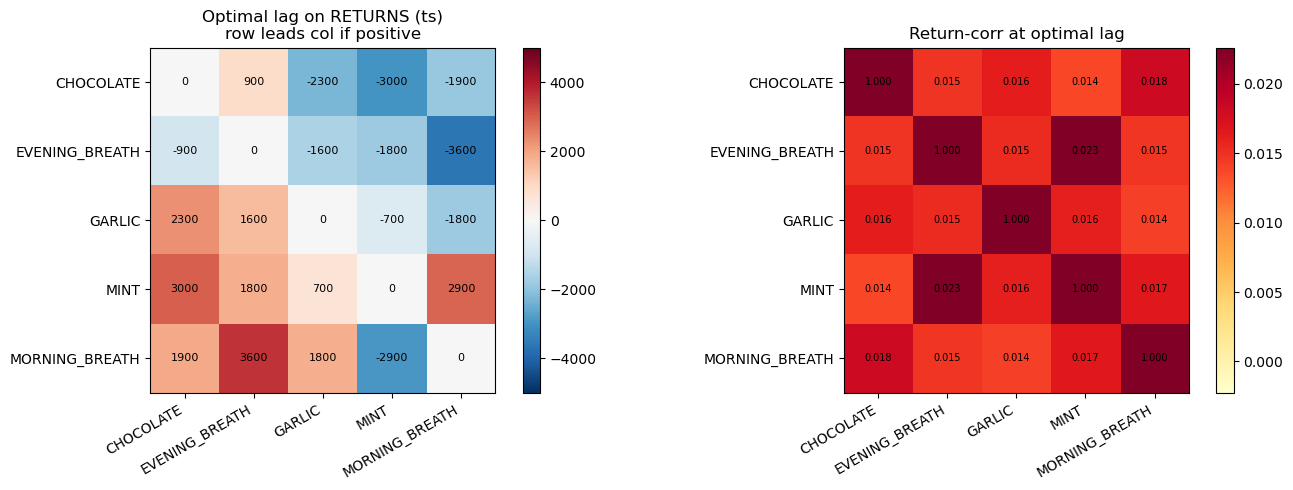


Return lead-lag (row leads col by N ts; only |lag|>0 and corr>0.02 shown):
  MINT                 leads EVENING_BREATH       by +1800 ts  corr=0.0226


In [8]:
# ── Lead-lag on RETURNS (first differences), not levels ─────────────────────
# Levels view (prior cell) hits the +/-1M cap on most pairs because all 5 mids
# are stationary near a common mean — that's MVN-in-levels noise, not lead-lag.
# Real predictive structure lives in returns: corr(leader_diff[t-k], lagger_diff[t]).
from tqdm.auto import tqdm

filled_lvl = mids[sleep_cols].ffill()
ret = filled_lvl.diff()
ret_clean = ret.dropna(how='any')
n = len(sleep_cols)

MAX_LAG_TS_R = 5_000   # +/- 50 ticks at ts_step=100
ts_step      = int(filled_lvl.index[1] - filled_lvl.index[0])
max_lag_idx  = MAX_LAG_TS_R // ts_step

lag_idxs = np.arange(-max_lag_idx, max_lag_idx + 1)
opt_lag_r  = np.zeros((n, n), dtype=int)
opt_corr_r = np.zeros((n, n))

R = ret_clean.values  # rows=time, cols=products
for i in tqdm(range(n), desc="leader"):
    for j in range(n):
        if i == j:
            opt_lag_r[i, j] = 0; opt_corr_r[i, j] = 1.0; continue
        a = R[:, i]; b = R[:, j]
        best_c = -1.0; best_l = 0
        for l in lag_idxs:
            if l >= 0:
                x = a[:len(a)-l] if l > 0 else a
                y = b[l:]        if l > 0 else b
            else:
                x = a[-l:]
                y = b[:len(b)+l]
            if len(x) < 100: continue
            c = np.corrcoef(x, y)[0, 1]
            if c > best_c:
                best_c = c; best_l = l
        opt_lag_r[i, j]  = best_l * ts_step
        opt_corr_r[i, j] = best_c

short_names = [c.replace("OXYGEN_SHAKE_", "") for c in sleep_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(opt_lag_r, cmap="RdBu_r", vmin=-MAX_LAG_TS_R, vmax=MAX_LAG_TS_R)
axes[0].set_title("Optimal lag on RETURNS (ts)\nrow leads col if positive")
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(short_names, rotation=30, ha="right")
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, opt_lag_r[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(opt_corr_r, cmap="YlOrRd", vmin=opt_corr_r[opt_corr_r<1].max()*-0.1, vmax=opt_corr_r[opt_corr_r<1].max())
axes[1].set_title("Return-corr at optimal lag")
axes[1].set_xticks(range(n)); axes[1].set_xticklabels(short_names, rotation=30, ha="right")
axes[1].set_yticks(range(n)); axes[1].set_yticklabels(short_names)
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, f"{opt_corr_r[i, j]:.3f}", ha="center", va="center", fontsize=7)
plt.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()

print(f"\nReturn lead-lag (row leads col by N ts; only |lag|>0 and corr>0.02 shown):")
for i, a in enumerate(short_names):
    for j, b in enumerate(short_names):
        if i == j: continue
        lag = opt_lag_r[i, j]; c = opt_corr_r[i, j]
        if lag > 0 and c > 0.02:
            print(f"  {a:20s} leads {b:20s} by {lag:+d} ts  corr={c:.4f}")


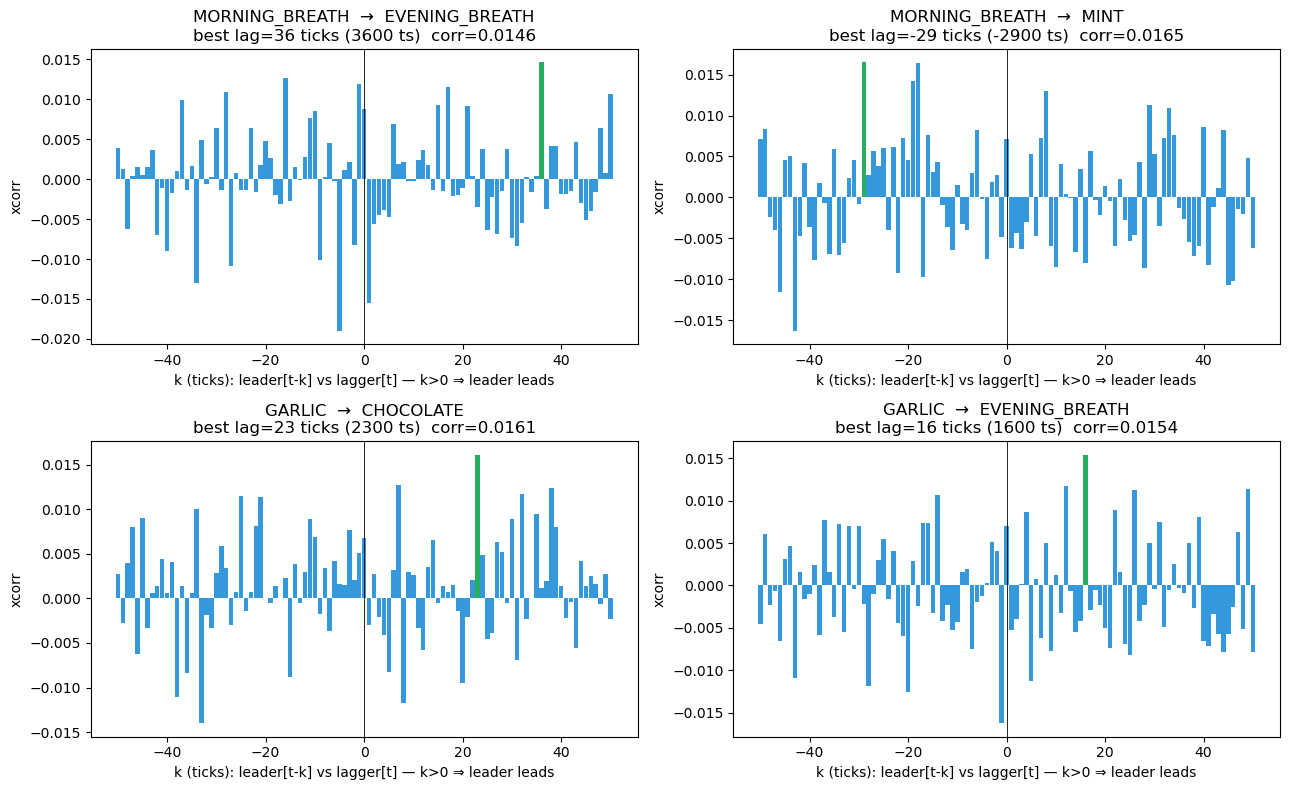

Interpretation: bars to the RIGHT of 0 with green peak ⇒ claim confirmed.
If peak is at k=0 or k<0, leader doesn't actually lead on returns.


In [9]:
# ── Validate user-claimed leaders: MORNING_BREATH→{EVENING_BREATH,MINT}, GARLIC→{CHOCOLATE,EVENING_BREATH} ──
# For each claim, plot xcorr(leader_ret[t-k], lagger_ret[t]) for k in [-50..50] ticks.
# Positive k with positive corr = leader actually leads.

claims = [
    ("OXYGEN_SHAKE_MORNING_BREATH", "OXYGEN_SHAKE_EVENING_BREATH"),
    ("OXYGEN_SHAKE_MORNING_BREATH", "OXYGEN_SHAKE_MINT"),
    ("OXYGEN_SHAKE_GARLIC",         "OXYGEN_SHAKE_CHOCOLATE"),
    ("OXYGEN_SHAKE_GARLIC",         "OXYGEN_SHAKE_EVENING_BREATH"),
]
LAGS = np.arange(-50, 51)  # ticks (1 tick = 100 ts)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (lead, lag) in zip(axes.flat, claims):
    a = ret_clean[lead].values
    b = ret_clean[lag].values
    cs = []
    for k in LAGS:
        if k >= 0:
            x = a[:len(a)-k] if k > 0 else a
            y = b[k:]        if k > 0 else b
        else:
            x = a[-k:]
            y = b[:len(b)+k]
        cs.append(np.corrcoef(x, y)[0, 1])
    cs = np.array(cs)
    best_idx = int(np.argmax(cs))
    best_lag = int(LAGS[best_idx])
    ax.bar(LAGS, cs, color=['#27ae60' if l == best_lag else '#3498db' for l in LAGS], width=0.9)
    ax.axvline(0, color='k', linewidth=0.6)
    ax.set_title(f"{lead.replace('OXYGEN_SHAKE_','')}  →  {lag.replace('OXYGEN_SHAKE_','')}\n"
                 f"best lag={best_lag} ticks ({best_lag*100} ts)  corr={cs[best_idx]:.4f}")
    ax.set_xlabel("k (ticks): leader[t-k] vs lagger[t] — k>0 ⇒ leader leads")
    ax.set_ylabel("xcorr")
plt.tight_layout(); plt.show()

print("Interpretation: bars to the RIGHT of 0 with green peak ⇒ claim confirmed.")
print("If peak is at k=0 or k<0, leader doesn't actually lead on returns.")


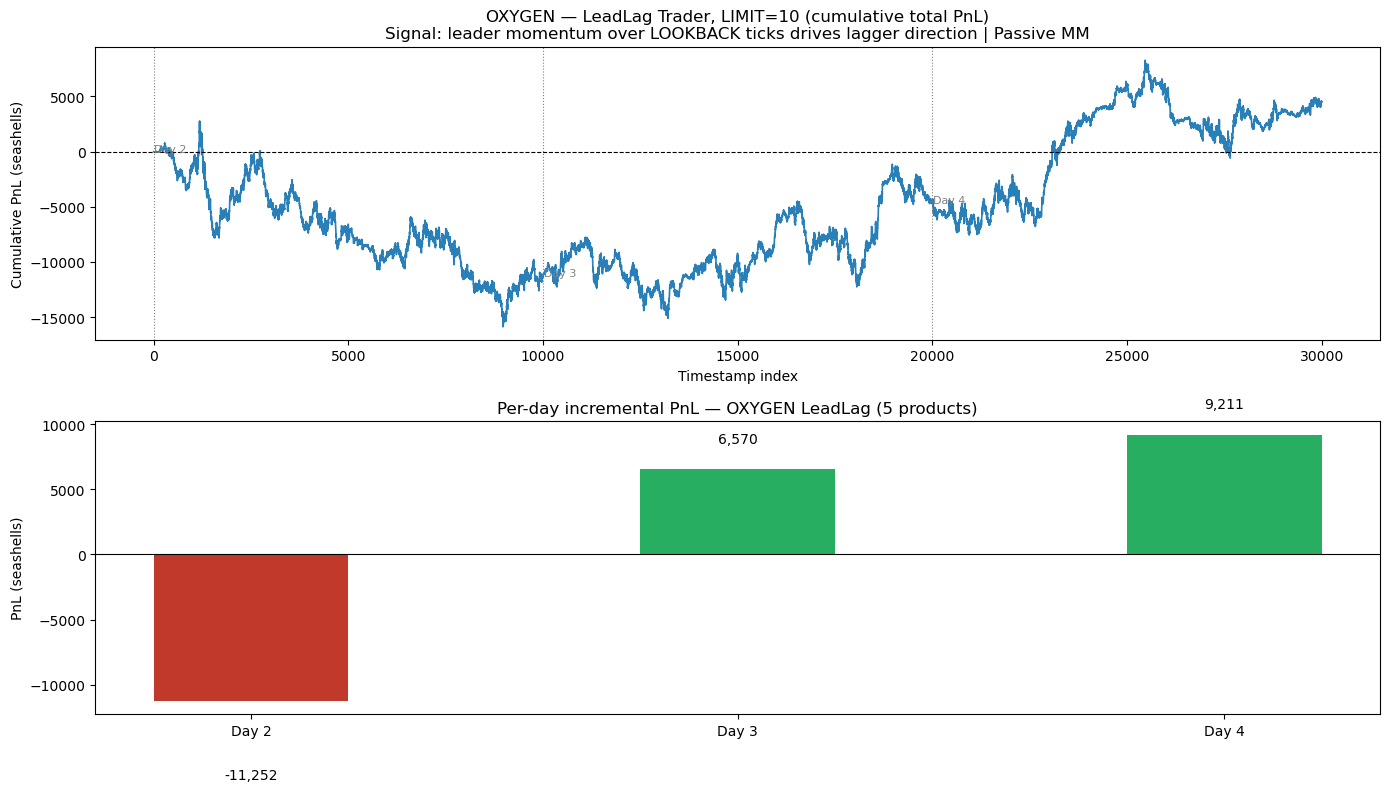

Per-product incremental PnL:
  product                   Day2        Day3        Day4       Total
  CHOCOLATE               +4,946      +5,684      +8,475     +19,105
  EVENING_BREATH         -10,109      +8,606      +3,132      +1,629
  GARLIC                      +0          +0          +0          +0
  MINT                    -6,089      -7,720      -2,396     -16,205
  MORNING_BREATH              +0          +0          +0          +0

Total PnL (all 5 products):
  Day 2: -11,252
  Day 3: +6,570
  Day 4: +9,211
  Grand Total: +4,529

Final positions: {'CHOCOLATE': 3, 'EVENING_BREATH': 2, 'GARLIC': 0, 'MINT': 3, 'MORNING_BREATH': 0}


In [11]:
# ── Backtester + OxygenLeadLagTrader ──────────────────────────────────────────
import sys
import json as _json
from collections import defaultdict, deque

sys.path.insert(0, '..')
from datamodel import TradingState, Listing, OrderDepth, Trade, Order, Observation


class Backtester:
    def __init__(self, trader, listings, position_limit, fair_marks, market_data, trade_history):
        self.trader           = trader
        self.listings         = listings
        self.market_data      = market_data.copy()
        self.position_limit   = position_limit
        self.fair_marks       = fair_marks
        self.trade_history    = trade_history.sort_values(by=['timestamp', 'symbol'])
        self.observations     = [Observation({}, {}) for _ in range(len(market_data))]
        self.current_position = {p: 0 for p in listings}
        self.pnl_history      = []
        self.pnl              = {p: 0 for p in listings}
        self.cash             = {p: 0 for p in listings}

    def run(self):
        traderData    = ''
        ts_md         = self.market_data.groupby('timestamp')
        own_trades    = defaultdict(list)
        market_trades = defaultdict(list)

        trade_hist_dict = {}
        for ts, grp in self.trade_history.groupby('timestamp'):
            trade_hist_dict[ts] = [
                Trade(row['symbol'], int(row['price']), int(row['quantity']),
                      row['buyer'] if pd.notnull(row.get('buyer', '')) else '',
                      row['seller'] if pd.notnull(row.get('seller', '')) else '', ts)
                for _, row in grp.iterrows()
            ]

        for ts, grp in ts_md:
            od_trade = self._build_od(grp)
            od_pnl   = self._build_od(grp)
            state    = TradingState(traderData, ts, self.listings, od_trade,
                                    dict(own_trades), dict(market_trades),
                                    self.current_position, self.observations[0])
            orders, _, traderData = self.trader.run(state)

            products = grp['product'].tolist()

            bids_snap = {}; asks_snap = {}
            for prod in products:
                od = od_trade.get(prod)
                if od and od.buy_orders:  bids_snap[prod] = max(od.buy_orders)
                if od and od.sell_orders: asks_snap[prod] = min(od.sell_orders)

            passive_orders = defaultdict(list)
            for prod in products:
                for order in orders.get(prod, []):
                    done, _ = self._execute(ts, order, od_trade, self.current_position,
                                            self.cash, trade_hist_dict, '')
                    if done:
                        own_trades[prod].extend(done)
                    if order.quantity != 0:
                        passive_orders[prod].append(order)

            t_at_ts = trade_hist_dict.get(ts, [])
            for mt in t_at_ts:
                prod = mt.symbol
                if prod not in passive_orders:
                    continue
                bid = bids_snap.get(prod); ask = asks_snap.get(prod)
                mt_rem = mt.quantity
                for po in passive_orders[prod]:
                    if mt_rem <= 0: break
                    if po.quantity > 0 and bid is not None and mt.price <= bid:
                        vol = min(po.quantity, mt_rem,
                                  int(self.position_limit[prod]) - self.current_position[prod])
                        if vol > 0:
                            own_trades[prod].append(Trade(prod, po.price, vol, 'SUBMISSION', '', ts))
                            self.current_position[prod] += vol
                            self.cash[prod] -= po.price * vol
                            po.quantity -= vol; mt_rem -= vol
                    elif po.quantity < 0 and ask is not None and mt.price >= ask:
                        vol = min(abs(po.quantity), mt_rem,
                                  int(self.position_limit[prod]) + self.current_position[prod])
                        if vol > 0:
                            own_trades[prod].append(Trade(prod, po.price, vol, '', 'SUBMISSION', ts))
                            self.current_position[prod] -= vol
                            self.cash[prod] += po.price * vol
                            po.quantity += vol; mt_rem -= vol

            if t_at_ts:
                for t in t_at_ts: market_trades[t.symbol].append(t)
            else:
                for prod in products: market_trades[prod] = []

            for prod in products:
                self._mark(od_pnl, prod)
                self.pnl_history.append(self.pnl[prod])

        return self.pnl

    def _build_od(self, grp):
        od_map = {}
        for _, row in grp.iterrows():
            prod = row['product']; od = OrderDepth()
            for i in range(1, 4):
                bp, bv = row.get(f'bid_price_{i}'), row.get(f'bid_volume_{i}')
                ap, av = row.get(f'ask_price_{i}'), row.get(f'ask_volume_{i}')
                if pd.notna(bp) and pd.notna(bv) and str(bp) != '' and str(bv) != '':
                    od.buy_orders[int(float(bp))]  =  int(float(bv))
                if pd.notna(ap) and pd.notna(av) and str(ap) != '' and str(av) != '':
                    od.sell_orders[int(float(ap))] = -int(float(av))
            od_map[prod] = od
        return od_map

    def _mark(self, od_map, prod):
        od = od_map.get(prod)
        if od is None or not od.buy_orders or not od.sell_orders: return
        mid  = (max(od.buy_orders) + min(od.sell_orders)) / 2.0
        fair = self.fair_marks[prod](od) if prod in self.fair_marks else mid
        self.pnl[prod] = self.cash[prod] + fair * self.current_position[prod]

    def _execute(self, ts, order, od_map, pos, cash, hist, log):
        return (self._buy if order.quantity > 0 else self._sell)(ts, order, od_map, pos, cash, hist, log)

    def _buy(self, ts, order, od_map, pos, cash, hist, log):
        trades, od = [], od_map[order.symbol]
        for price in sorted(od.sell_orders):
            if price > order.price or order.quantity == 0: break
            vol = min(order.quantity, abs(od.sell_orders[price]),
                      int(self.position_limit[order.symbol]) - pos[order.symbol])
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, 'SUBMISSION', '', ts))
                pos[order.symbol] += vol; cash[order.symbol] -= price * vol
                od.sell_orders[price] += vol; order.quantity -= vol
            if od.sell_orders.get(price) == 0: del od.sell_orders[price]
        return trades, log

    def _sell(self, ts, order, od_map, pos, cash, hist, log):
        trades, od = [], od_map[order.symbol]
        for price in sorted(od.buy_orders, reverse=True):
            if price < order.price or order.quantity == 0: break
            vol = min(abs(order.quantity), od.buy_orders[price],
                      int(self.position_limit[order.symbol]) + pos[order.symbol])
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, '', 'SUBMISSION', ts))
                pos[order.symbol] -= vol; cash[order.symbol] += price * vol
                od.buy_orders[price] -= vol; order.quantity += vol
            if od.buy_orders.get(price) == 0: del od.buy_orders[price]
        return trades, log


# ── OxygenLeadLagTrader ────────────────────────────────────────────────────────
class OxygenLeadLagTrader:
    """
    Hypothesis (validated above on returns):
      MORNING_BREATH leads EVENING_BREATH and MINT
      GARLIC         leads CHOCOLATE and EVENING_BREATH

    Signal per lagger = sign of leader's mid change over last LOOKBACK ticks,
    averaged across that lagger's leaders.

    Execution: passive MM at lagger's bid (long) or ask (short).
    Quote MM_SIZE per tick, target full position limit in signal direction.
    """
    LIMIT     = 10
    MM_SIZE   = 4
    LOOKBACK  = 5  # ticks of leader history to evaluate momentum

    LEAD_LAG = {
        # lagger : [leaders]
        "OXYGEN_SHAKE_EVENING_BREATH": ["OXYGEN_SHAKE_MORNING_BREATH", "OXYGEN_SHAKE_GARLIC"],
        "OXYGEN_SHAKE_MINT":           ["OXYGEN_SHAKE_MORNING_BREATH"],
        "OXYGEN_SHAKE_CHOCOLATE":      ["OXYGEN_SHAKE_GARLIC"],
    }
    ALL_PRODUCTS = [
        "OXYGEN_SHAKE_MORNING_BREATH", "OXYGEN_SHAKE_EVENING_BREATH",
        "OXYGEN_SHAKE_MINT", "OXYGEN_SHAKE_GARLIC", "OXYGEN_SHAKE_CHOCOLATE",
    ]

    def __init__(self):
        self.history = {p: deque(maxlen=self.LOOKBACK + 1) for p in self.ALL_PRODUCTS}

    def run(self, state: TradingState):
        orders = {}
        bids = {}; asks = {}; mids = {}
        for sym in self.ALL_PRODUCTS:
            od = state.order_depths.get(sym)
            if od and od.buy_orders and od.sell_orders:
                bids[sym] = max(od.buy_orders)
                asks[sym] = min(od.sell_orders)
                mids[sym] = (bids[sym] + asks[sym]) / 2.0
                self.history[sym].append(mids[sym])

        for lagger, leaders in self.LEAD_LAG.items():
            if lagger not in mids: continue

            sigs = []
            for ldr in leaders:
                h = self.history.get(ldr)
                if h and len(h) >= 2:
                    sigs.append(h[-1] - h[0])
            if not sigs: continue
            sig = sum(sigs) / len(sigs)
            if sig == 0: continue

            direction = 1 if sig > 0 else -1
            pos    = state.position.get(lagger, 0)
            target = direction * self.LIMIT
            needed = target - pos
            if needed == 0: continue
            qty = min(abs(needed), self.MM_SIZE)
            if needed > 0:
                orders[lagger] = [Order(lagger, bids[lagger], qty)]
            else:
                orders[lagger] = [Order(lagger, asks[lagger], -qty)]

        return orders, 0, state.traderData


# ── Load trade history ─────────────────────────────────────────────────────────
trade_rows, offset = [], 0
for day in DAYS:
    with open(f'./{BASE}/trades_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)
    offset += 1_000_000

all_trades = pd.DataFrame(trade_rows)
all_trades['timestamp'] = pd.to_numeric(all_trades['timestamp'])
all_trades['price']     = pd.to_numeric(all_trades['price'],    errors='coerce')
all_trades['quantity']  = pd.to_numeric(all_trades['quantity'], errors='coerce')
oxy_trades = all_trades[all_trades['symbol'].str.startswith('OXYGEN', na=False)].copy()
if 'buyer'  not in oxy_trades.columns: oxy_trades['buyer']  = ''
if 'seller' not in oxy_trades.columns: oxy_trades['seller'] = ''

# ── Run backtest ───────────────────────────────────────────────────────────────
OXY_PRODUCTS = list(prices['product'].unique())
POS_LIMIT    = 10

listings = {p: Listing(p, p, 'SEASHELLS') for p in OXY_PRODUCTS}
pos_lim  = {p: POS_LIMIT for p in OXY_PRODUCTS}

trader     = OxygenLeadLagTrader()
backtester = Backtester(trader, listings, pos_lim, {}, prices, oxy_trades)
final_pnl  = backtester.run()

# ── Align PnL to market data rows ─────────────────────────────────────────────
md_with_pnl = prices.copy().reset_index(drop=True)
md_with_pnl['pnl'] = backtester.pnl_history

DAY_BOUNDS = [(0, 1_000_000), (1_000_000, 2_000_000), (2_000_000, 3_000_000)]

pnl_by_prod = {}
for prod in OXY_PRODUCTS:
    s = md_with_pnl[md_with_pnl['product'] == prod].set_index('timestamp')['pnl']
    pnl_by_prod[prod] = s

prod_day_pnl = {}; prev_cum = {prod: 0.0 for prod in OXY_PRODUCTS}
for d, (lo, hi) in enumerate(DAY_BOUNDS, 2):
    for prod in OXY_PRODUCTS:
        s = pnl_by_prod[prod]; mask = (s.index >= lo) & (s.index < hi)
        if mask.any():
            cum = s[mask].iloc[-1]
            prod_day_pnl.setdefault(prod, {})[f'Day {d}'] = cum - prev_cum[prod]
            prev_cum[prod] = cum

total_pnl_by_day = {f'Day {d}': sum(prod_day_pnl.get(prod, {}).get(f'Day {d}', 0)
                                    for prod in OXY_PRODUCTS)
                    for d in range(2, 5)}
total_cum_pnl = md_with_pnl.groupby('timestamp')['pnl'].sum()

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(total_cum_pnl.values, color='#2980b9', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for d, (lo, hi) in enumerate(DAY_BOUNDS, 2):
    idx_arr = np.where(total_cum_pnl.index >= lo)[0]
    if len(idx_arr):
        axes[0].axvline(idx_arr[0], color='gray', linewidth=0.8, linestyle=':')
        axes[0].text(idx_arr[0] + 20, total_cum_pnl.values[idx_arr[0]], f'Day {d}', fontsize=8, color='gray')
axes[0].set_title('OXYGEN — LeadLag Trader, LIMIT=10 (cumulative total PnL)\n'
                  'Signal: leader momentum over LOOKBACK ticks drives lagger direction | Passive MM')
axes[0].set_ylabel('Cumulative PnL (seashells)')
axes[0].set_xlabel('Timestamp index')

colors = ['#27ae60' if v >= 0 else '#c0392b' for v in total_pnl_by_day.values()]
axes[1].bar(total_pnl_by_day.keys(), total_pnl_by_day.values(), color=colors, width=0.4)
axes[1].axhline(0, color='black', linewidth=0.8)
for i, (label, val) in enumerate(total_pnl_by_day.items()):
    axes[1].text(i, val + (2000 if val >= 0 else -6000), f'{val:,.0f}', ha='center', fontsize=10)
axes[1].set_title('Per-day incremental PnL — OXYGEN LeadLag (5 products)')
axes[1].set_ylabel('PnL (seashells)')
plt.tight_layout(); plt.show()

short_name = lambda p: p.replace('OXYGEN_SHAKE_', '')
print('Per-product incremental PnL:')
print(f"  {'product':18s}  {'Day2':>10s}  {'Day3':>10s}  {'Day4':>10s}  {'Total':>10s}")
for prod in OXY_PRODUCTS:
    d2  = prod_day_pnl.get(prod, {}).get('Day 2', 0)
    d3  = prod_day_pnl.get(prod, {}).get('Day 3', 0)
    d4  = prod_day_pnl.get(prod, {}).get('Day 4', 0)
    tot = d2 + d3 + d4
    print(f"  {short_name(prod):18s}  {d2:>+10,.0f}  {d3:>+10,.0f}  {d4:>+10,.0f}  {tot:>+10,.0f}")

print(f'\nTotal PnL (all 5 products):')
for label, val in total_pnl_by_day.items():
    print(f'  {label}: {val:>+,.0f}')
grand = sum(total_pnl_by_day.values())
print(f'  Grand Total: {grand:>+,.0f}')
print(f"\nFinal positions: { {short_name(k): v for k, v in backtester.current_position.items()} }")
